# Time-Aware Lag Modeling and Interpretability

## Goal
This notebook does the follow-up work:

1. compare **linear coefficients** vs **tree importances**
2. check **feature-importance stability** across multiple seeds
3. create **partial dependence plots** for the strongest tree features
4. build a **lag-based forecasting baseline** using prior-year country history

In [1]:
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

sys.path.append(str(PROJECT_ROOT / "src"))

REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import PartialDependenceDisplay

from data.feature_engineering import build_feature_sets_abc
from modeling.advanced_models import get_timeaware_model_registry
from modeling.experiment_runner import run_time_experiment, top_n_worst_predictions, grouped_mae
from modeling.temporal import make_country_lag_features

TARGET = "life_expectancy"
YEAR_COL = "year"
TEST_YEARS = 3
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

In [4]:
data_candidates = [
    PROJECT_ROOT / "data" / "processed" / "main_dataset.csv",
    PROJECT_ROOT / "data" / "processed" / "panel_dataset.csv",
]

DATA_PATH = None
for p in data_candidates:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find processed dataset. Expected one of:\n"
        + "\n".join(str(p) for p in data_candidates)
    )

raw_df = pd.read_csv(DATA_PATH)
model_df, feature_sets, feature_meta = build_feature_sets_abc(
    raw_df,
    target_col=TARGET,
    year_col=YEAR_COL,
    corr_threshold=0.90,
    vif_threshold=10.0,
)

model_df.shape, {k: len(v) for k, v in feature_sets.items()}

/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encount

((2265, 39), {'A': 38, 'B': 31, 'C': 5})

## Linear coefficients vs tree importances
To keep this comparison interpretable, use Feature Set C (the smaller manually reduced set).

In [5]:
registry = get_timeaware_model_registry(random_state=RANDOM_STATE)

ridge_row, ridge_pred, ridge_split, ridge_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="RidgeCV",
    model=registry["RidgeCV"]["model"],
    scale_mode=registry["RidgeCV"]["scale_mode"],
    test_years=TEST_YEARS,
    run_log_path=REPORT_TABLES / "week10_week11_run_log.csv",
    split_label="time_C",
)

rf_row, rf_pred, rf_split, rf_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="RandomForest",
    model=registry["RandomForest"]["model"],
    scale_mode=registry["RandomForest"]["scale_mode"],
    test_years=TEST_YEARS,
    run_log_path=REPORT_TABLES / "week10_week11_run_log.csv",
    split_label="time_C",
)

et_row, et_pred, et_split, et_pipe = run_time_experiment(
    df=model_df,
    feature_list=feature_sets["C"],
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="ExtraTrees",
    model=registry["ExtraTrees"]["model"],
    scale_mode=registry["ExtraTrees"]["scale_mode"],
    test_years=TEST_YEARS,
    run_log_path=REPORT_TABLES / "week10_week11_run_log.csv",
    split_label="time_C",
)

pd.DataFrame([ridge_row, rf_row, et_row]).sort_values("rmse")

,model_name,split_name,n_train,n_test,rmse,mae,r2
2,ExtraTrees,time_C,1812,453,3.479168,2.756938,0.827274
1,RandomForest,time_C,1812,453,3.956145,3.067658,0.776668
0,RidgeCV,time_C,1812,453,6.149633,5.215115,0.460359


In [6]:
ridge_coef_df = pd.DataFrame(
    {
        "feature": feature_sets["C"],
        "ridge_coef": ridge_pipe.named_steps["model"].coef_,
        "ridge_abs_coef": np.abs(ridge_pipe.named_steps["model"].coef_),
    }
).sort_values("ridge_abs_coef", ascending=False)

rf_importance_df = pd.DataFrame(
    {
        "feature": feature_sets["C"],
        "rf_importance": rf_pipe.named_steps["model"].feature_importances_,
    }
).sort_values("rf_importance", ascending=False)

et_importance_df = pd.DataFrame(
    {
        "feature": feature_sets["C"],
        "et_importance": et_pipe.named_steps["model"].feature_importances_,
    }
).sort_values("et_importance", ascending=False)

driver_compare = (
    ridge_coef_df[["feature", "ridge_coef", "ridge_abs_coef"]]
    .merge(rf_importance_df, on="feature", how="outer")
    .merge(et_importance_df, on="feature", how="outer")
)

driver_compare.to_csv(REPORT_TABLES / "week11_driver_compare_C.csv", index=False)
driver_compare

,feature,ridge_coef,ridge_abs_coef,rf_importance,et_importance
0,hiv_aids,-4.866201,4.866201,0.704834,0.545950
1,infant_deaths,-1.092126,1.092126,0.111985,0.102371
2,percentage_expenditure,1.972507,1.972507,0.144338,0.112395
3,status_flag,2.635828,2.635828,0.015948,0.215914
4,year,0.507397,0.507397,0.022895,0.023370


## Importance stability across random seeds
This checks whether the tree-based importance ranking is stable or highly seed-dependent.

In [7]:
from sklearn.ensemble import RandomForestRegressor

stability_rows = []

for seed in [42, 43, 44]:
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=seed,
        n_jobs=-1,
    )
    row, pred_df, split_info, pipe = run_time_experiment(
        df=model_df,
        feature_list=feature_sets["B"],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_name=f"RandomForest_seed{seed}",
        model=model,
        scale_mode="none",
        test_years=TEST_YEARS,
        run_log_path=REPORT_TABLES / "week10_week11_run_log.csv",
        split_label="time_B",
    )

    importances = pipe.named_steps["model"].feature_importances_
    for feat, imp in zip(feature_sets["B"], importances):
        stability_rows.append(
            {
                "seed": seed,
                "feature": feat,
                "importance": imp,
            }
        )

stability_df = pd.DataFrame(stability_rows)
stability_summary = (
    stability_df.groupby("feature")["importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

stability_df.to_csv(REPORT_TABLES / "week11_rf_importance_stability_raw.csv", index=False)
stability_summary.to_csv(REPORT_TABLES / "week11_rf_importance_stability_summary.csv", index=False)

stability_summary.head(15)

,feature,mean,std
0,hiv_aids,0.650853,0.000355
1,income_composition_of_resources,0.164396,0.001322
2,adult_mortality,0.082334,0.001962
3,infant_deaths,0.020168,0.000952
4,schooling,0.015609,0.000803
5,bmi,0.014650,0.000616
6,thinness_1_19_years,0.006956,0.000232
7,alcohol,0.005218,0.000296
8,undernourishment,0.003810,0.000187
9,health_expenditure_percent,0.003377,0.000168


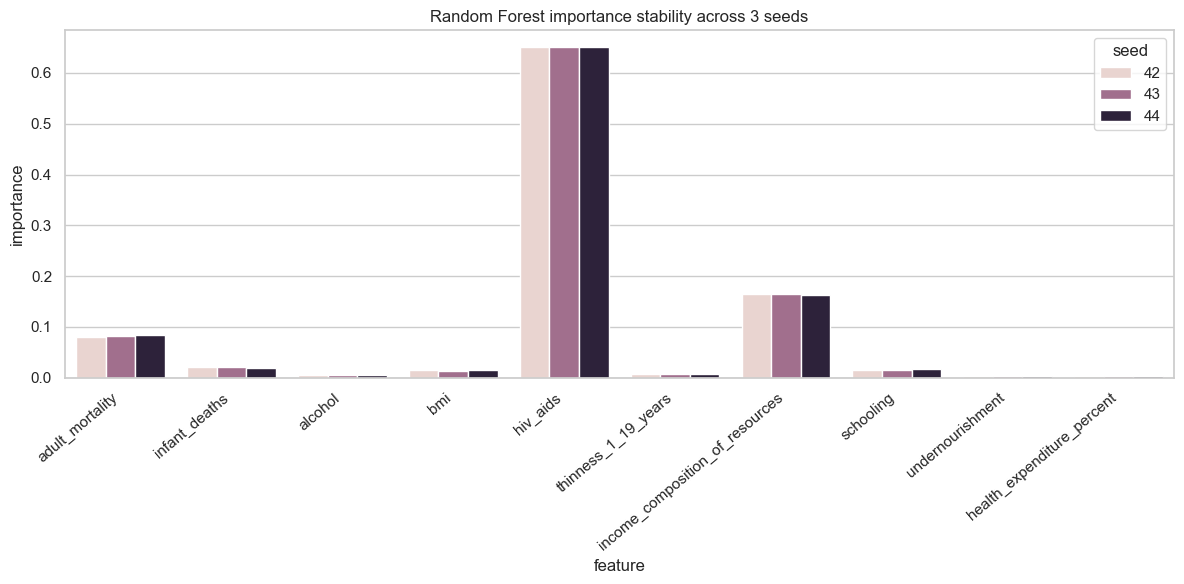

In [8]:
top_stable = stability_summary.head(10)["feature"].tolist()

plot_df = stability_df[stability_df["feature"].isin(top_stable)].copy()

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="feature", y="importance", hue="seed")
plt.title("Random Forest importance stability across 3 seeds")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week11_rf_importance_stability.png", dpi=200, bbox_inches="tight")
plt.show()

## Partial dependence for top tree features
Use the best tree model on Feature Set C so the plots remain readable.

In [9]:
best_tree_pipe = rf_pipe if rf_row["rmse"] <= et_row["rmse"] else et_pipe
best_tree_name = "RandomForest" if rf_row["rmse"] <= et_row["rmse"] else "ExtraTrees"

tree_importances = (
    rf_importance_df if best_tree_name == "RandomForest" else et_importance_df
).sort_values(
    "rf_importance" if best_tree_name == "RandomForest" else "et_importance",
    ascending=False,
)

top2_features = tree_importances["feature"].head(2).tolist()
top2_features

['hiv_aids', 'status_flag']

/Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_expectancy_env/lib/python3.14/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


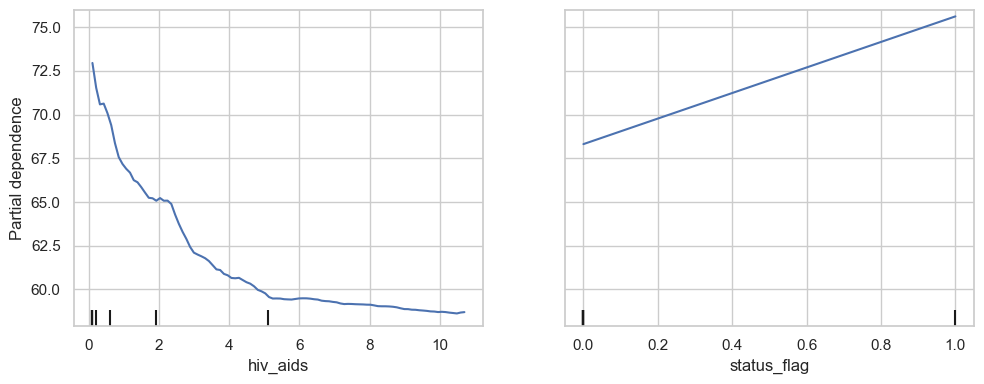

In [10]:
# Rebuild train split for PDP plotting
from modeling.splits import make_time_split

keep_cols = list(dict.fromkeys([*feature_sets["C"], TARGET, YEAR_COL]))
work_df = model_df[keep_cols].copy()
X_train, X_test, y_train, y_test, _ = make_time_split(
    work_df,
    target_col=TARGET,
    year_col=YEAR_COL,
    test_years=TEST_YEARS,
)

Xtr = X_train[feature_sets["C"]].copy()

fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    best_tree_pipe,
    Xtr,
    features=top2_features,
    ax=ax,
)
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week10_partial_dependence_top2.png", dpi=200, bbox_inches="tight")
plt.show()

## Lag-based forecasting baseline
This is the clean temporal extension: use previous country-year information to predict later life expectancy on the same time-aware split.

In [11]:
from data.feature_engineering import prepare_numeric_model_frame

# Rebuild a country-aware numeric frame
country_cols = [c for c in ["country", "country_code", "region", "income_group"] if c in raw_df.columns]
base_numeric = prepare_numeric_model_frame(raw_df, target_col=TARGET, year_col=YEAR_COL)

country_frame = raw_df[country_cols + [YEAR_COL]].copy()
country_frame[YEAR_COL] = pd.to_numeric(country_frame[YEAR_COL], errors="raise").astype(int)

lag_source_df = pd.concat([country_frame.reset_index(drop=True), base_numeric.reset_index(drop=True)], axis=1)
lag_source_df = lag_source_df.loc[:, ~lag_source_df.columns.duplicated()]
lag_source_df = lag_source_df.dropna(subset=["country", YEAR_COL, TARGET]).copy()

lag_source_df.head()

,country,country_code,region,income_group,year,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,...,gdp_log1p,population_log1p,co2_log1p,gdp_missing_flag,schooling_missing_flag,sanitation_missing_flag,adult_mortality_missing_flag,schooling__x__status_flag,gdp_log1p__x__status_flag,life_expectancy
0,Afghanistan,AFG,South Asia,Low income,2015,263.0,62,0.01,71.279624,65.0,...,6.372055,17.334091,8.691315,0,0,1,0,0.0,0.0,64.1885
1,Afghanistan,AFG,South Asia,Low income,2014,271.0,64,0.01,73.523582,62.0,...,6.419501,12.699497,8.493105,0,0,1,0,0.0,0.0,61.4330
2,Afghanistan,AFG,South Asia,Low income,2013,268.0,66,0.01,73.219243,64.0,...,6.450067,17.272826,8.698014,0,0,1,0,0.0,0.0,61.2125
3,Afghanistan,AFG,South Asia,Low income,2012,272.0,69,0.01,78.184215,67.0,...,6.508708,15.123021,8.997271,0,0,1,0,0.0,0.0,60.7770
4,Afghanistan,AFG,South Asia,Low income,2011,275.0,71,0.01,7.097109,68.0,...,4.167242,14.906964,9.097284,0,0,1,0,0.0,0.0,60.3765


In [12]:
lag_base_features = [f for f in feature_sets["C"] if f != YEAR_COL]

lagged_df = make_country_lag_features(
    lag_source_df,
    target_col=TARGET,
    country_col="country",
    year_col=YEAR_COL,
    feature_cols=lag_base_features,
    lags=(1, 2, 3),
    dropna_lagged=True,
)

lag_feature_cols = [
    c for c in lagged_df.columns
    if c not in {"country", "country_code", "region", "income_group", TARGET}
]

len(lag_feature_cols), lagged_df.shape

(54, (1812, 59))

In [14]:
lag_ridge_row, lag_ridge_pred, lag_ridge_split, lag_ridge_pipe = run_time_experiment(
    df=lagged_df,
    feature_list=lag_feature_cols,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="LagRidgeCV",
    model=registry["RidgeCV"]["model"],
    scale_mode=registry["RidgeCV"]["scale_mode"],
    test_years=TEST_YEARS,
    run_log_path=REPORT_TABLES / "week10_week11_run_log.csv",
    split_label="time_lagged",
)

lag_hgb_row, lag_hgb_pred, lag_hgb_split, lag_hgb_pipe = run_time_experiment(
    df=lagged_df,
    feature_list=lag_feature_cols,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="LagHistGBR",
    model=registry["HistGBR"]["model"],
    scale_mode=registry["HistGBR"]["scale_mode"],
    test_years=TEST_YEARS,
    run_log_path=REPORT_TABLES / "week10_week11_run_log.csv",
    split_label="time_lagged",
)

lag_compare = pd.DataFrame([lag_ridge_row, lag_hgb_row]).sort_values("rmse")
lag_compare.to_csv(REPORT_TABLES / "week10_lag_model_compare.csv", index=False)
lag_compare

,model_name,split_name,n_train,n_test,rmse,mae,r2
1,LagHistGBR,time_lagged,1359,453,0.773434,0.461952,0.991464
0,LagRidgeCV,time_lagged,1359,453,0.931868,0.530336,0.987609


In [15]:
best_lag_pred = lag_ridge_pred if lag_ridge_row["rmse"] <= lag_hgb_row["rmse"] else lag_hgb_pred
best_lag_name = "LagRidgeCV" if lag_ridge_row["rmse"] <= lag_hgb_row["rmse"] else "LagHistGBR"

lag_worst10 = top_n_worst_predictions(best_lag_pred, n=10)
lag_mae_by_year = grouped_mae(best_lag_pred, "year")
lag_mae_by_region = grouped_mae(best_lag_pred, "region") if "region" in best_lag_pred.columns else None

lag_worst10.to_csv(REPORT_TABLES / "week11_lag_worst10.csv", index=False)
lag_mae_by_year.to_csv(REPORT_TABLES / "week11_lag_mae_by_year.csv", index=False)
if lag_mae_by_region is not None:
    lag_mae_by_region.to_csv(REPORT_TABLES / "week11_lag_mae_by_region.csv", index=False)

display(lag_worst10)
display(lag_mae_by_region.head(10) if lag_mae_by_region is not None else "No region column available")
display(lag_mae_by_year.head(10))

,country,year,y_true,y_pred,error,abs_error
0,South Africa,2013,65.049500,60.070088,-4.979412,4.979412
1,Iraq,2013,69.468500,73.357184,3.888684,3.888684
2,Trinidad and Tobago,2013,71.791000,75.500730,3.709730,3.709730
3,Germany,2014,85.045122,81.635773,-3.409349,3.409349
4,Zimbabwe,2015,63.267000,60.409428,-2.857572,2.857572
5,Angola,2013,54.577000,57.399429,2.822429,2.822429
6,Uganda,2013,63.440500,60.636794,-2.803706,2.803706
7,Finland,2014,85.090244,82.511654,-2.578590,2.578590
8,Afghanistan,2015,64.188500,61.726387,-2.462113,2.462113
9,Ukraine,2014,74.593293,72.185039,-2.408254,2.408254


'No region column available'

,year,mae
0,2013,0.495218
1,2014,0.494833
2,2015,0.395805


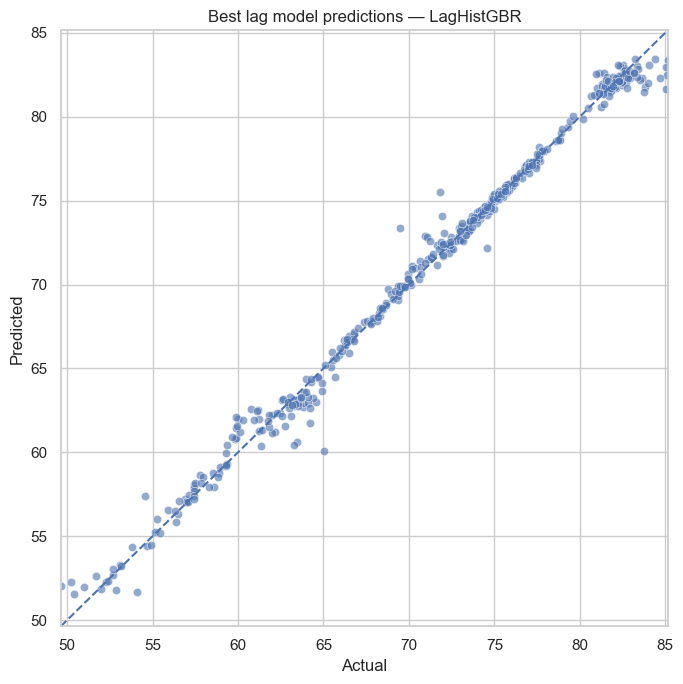

In [16]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_lag_pred, x="y_true", y="y_pred", alpha=0.6)
lims = [
    min(best_lag_pred["y_true"].min(), best_lag_pred["y_pred"].min()),
    max(best_lag_pred["y_true"].max(), best_lag_pred["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Best lag model predictions — {best_lag_name}")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "week11_best_lag_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()